In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

In [2]:
dataset = baseClasses.Data()

In [3]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 9, 20, 13, 45)) & (dataset.data.index < datetime.datetime(2024, 9, 20, 14, 30)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [4]:
with open("/eos/user/j/jcapotor/RTDdata/corrections/equalisation_sum.pkl", "rb") as f:
    equalisation = pickle.load(f)
print(equalisation)

{1: 0, 2: 2.5, 3: 19, 4: 41}


In [5]:
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

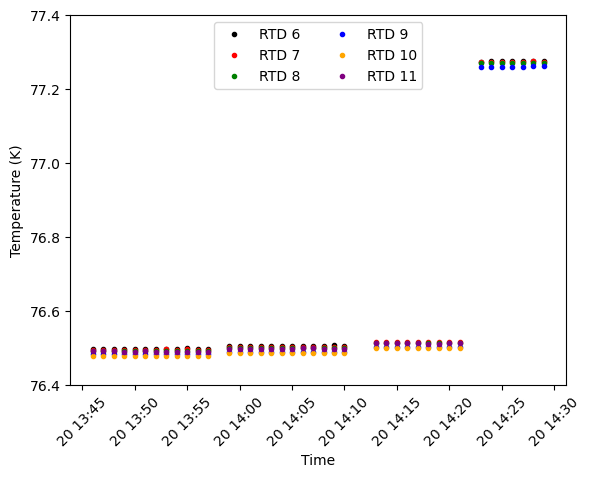

In [6]:
fig, axes = plt.subplots(1, 1)
axes.plot(dataset.data.index.values, (dataset.data['TE0007']/mux1.data).values, ".", label='RTD 6', color="black")
axes.plot(dataset.data.index.values, (dataset.data['TE0008']/mux1.data).values, ".", label='RTD 7', color="red")
axes.plot(dataset.data.index.values, (dataset.data['TE0009']/mux1.data).values, ".", label='RTD 8', color="green")
axes.plot(dataset.data.index.values, (dataset.data['TE0010']/mux1.data).values, ".", label='RTD 9', color="blue")
axes.plot(dataset.data.index.values, (dataset.data['TE0011']/mux1.data).values, ".", label='RTD 10', color="orange")
axes.plot(dataset.data.index.values, (dataset.data['TE0012']/mux1.data).values, ".", label='RTD 11', color="purple")
# axes.plot(dataset.data.index.values, dataset.data['TE0009'].values, ".", label='RTD 9')
axes.plot(dataset.data.index.values, (dataset.data['TE0025']/mux1.data).values, ".", color="black")
axes.plot(dataset.data.index.values, (dataset.data['TE0026']/mux2.data).values, ".", color="red")
axes.plot(dataset.data.index.values, (dataset.data['TE0027']/mux2.data).values, ".", color="green")
axes.plot(dataset.data.index.values, (dataset.data['TE0028']/mux2.data).values, ".", color="blue")
axes.plot(dataset.data.index.values, (dataset.data['TE0029']/mux2.data).values, ".", color="orange")
axes.plot(dataset.data.index.values, (dataset.data['TE0030']/mux2.data).values, ".", color="purple")

axes.plot(dataset.data.index.values, (dataset.data['TE0049']/mux3.data).values, ".", color="black")
axes.plot(dataset.data.index.values, (dataset.data['TE0050']/mux3.data).values, ".", color="red")
axes.plot(dataset.data.index.values, (dataset.data['TE0051']/mux3.data).values, ".", color="green")
axes.plot(dataset.data.index.values, (dataset.data['TE0052']/mux3.data).values, ".", color="blue")
axes.plot(dataset.data.index.values, (dataset.data['TE0053']/mux3.data).values, ".", color="orange")
axes.plot(dataset.data.index.values, (dataset.data['TE0054']/mux3.data).values, ".", color="purple")

axes.plot(dataset.data.index.values, (dataset.data['TE0073']*mux4.data/4).values, ".", color="black")
axes.plot(dataset.data.index.values, (dataset.data['TE0074']*mux4.data/4).values, ".", color="red")
axes.plot(dataset.data.index.values, (dataset.data['TE0075']*mux4.data/4).values, ".", color="green")
axes.plot(dataset.data.index.values, (dataset.data['TE0076']*mux4.data/4).values, ".", color="blue")
axes.plot(dataset.data.index.values, (dataset.data['TE0077']*mux4.data/4).values, ".", color="orange")
axes.plot(dataset.data.index.values, (dataset.data['TE0078']*mux4.data/4).values, ".", color="purple")

axes.set_ylim(76.4,77.4)
axes.set_xlabel("Time")
axes.set_ylabel("Temperature (K)")
axes.legend(ncol=2)
# axes.set_ylim(76,77)
axes.tick_params(axis='x', rotation=45);
# axes2 = axes.twinx()
# axes2.plot(mux1.data.index.values, mux1.data.values, "-.", label='MUX 1', color="blue")
# axes2.plot(mux2.data.index.values, mux2.data.values, "-.", label='MUX 2', color="black")
# axes2.plot(mux3.data.index.values, mux3.data.values, "-.", label='MUX 3', color="red")
# axes2.set_ylim(1.00075, 1.002)

Equalisation factors for B1: [1, 1, 1, 1, 1, 1]
Mean for B1: 1.0
Std for B1: 0.0
Equalisation factors for B2: [-0.005850375719333556, -0.006833387675357017, -0.0077318043208549625, -0.006643348593001974, -0.0069905890153449946, -0.007711980751992087]
Mean for B2: -0.006960247679314098
Std for B2: 0.0006467427514600052
Equalisation factors for B3: [-0.02142065268441229, -0.02218565957697649, -0.020496453526163805, -0.021211516904344307, -0.022223049662201788]
Mean for B3: -0.021507466470819737
Std for B3: 0.000646417070736273
Equalisation factors for B4: [-0.7765534640382157, -0.7776838574297784, -0.7784658027782712, -0.7769574076040442]
Mean for B4: -0.7774151329625774
Std for B4: 0.0007294014223898686
{'B1': {'mean': 1.0, 'std': 0.0}, 'B2': {'mean': -0.006960247679314098, 'std': 0.0006467427514600052}, 'B3': {'mean': -0.021507466470819737, 'std': 0.000646417070736273}, 'B4': {'mean': -0.7774151329625774, 'std': 0.0007294014223898686}}


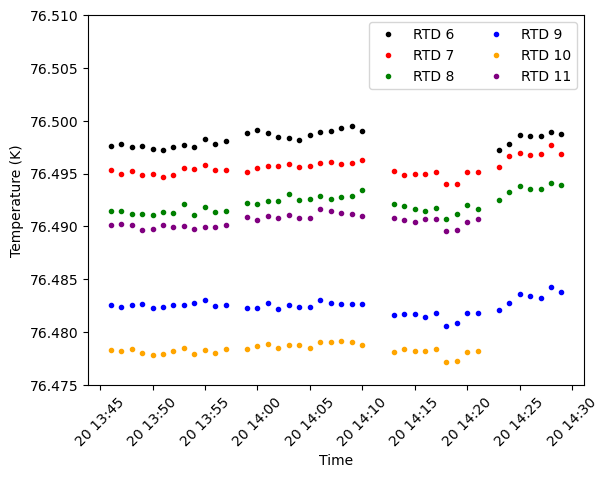

In [9]:
equalisation_values = {"B1":[1,1,1,1,1,1], "B2":[], "B3":[], "B4":[]}
fig, axes = plt.subplots(1, 1)
axes.plot(dataset.data.index.values, (dataset.data['TE0007']/mux1.data).values, ".", label='RTD 6', color="black")
axes.plot(dataset.data.index.values, (dataset.data['TE0008']/mux1.data).values, ".", label='RTD 7', color="red")
axes.plot(dataset.data.index.values, (dataset.data['TE0009']/mux1.data).values, ".", label='RTD 8', color="green")
axes.plot(dataset.data.index.values, (dataset.data['TE0010']/mux1.data).values, ".", label='RTD 9', color="blue")
axes.plot(dataset.data.index.values, (dataset.data['TE0011']/mux1.data).values, ".", label='RTD 10', color="orange")
axes.plot(dataset.data.index.values, (dataset.data['TE0012']/mux1.data).values, ".", label='RTD 11', color="purple")

for i in range(1, 7):
    denominator = (dataset.data[f'TE00{24+i}']/mux2.data).iloc[dataset.data.index == datetime.datetime(2024, 9, 20, 13, 59)].values[0]
    if i <= 3:
        numerator = (dataset.data[f'TE000{6+i}']/mux1.data).iloc[dataset.data.index == datetime.datetime(2024, 9, 20, 13, 57)].values[0]
    else:
        numerator = (dataset.data[f'TE00{6+i}']/mux1.data).iloc[dataset.data.index == datetime.datetime(2024, 9, 20, 13, 57)].values[0]
    factor = numerator - denominator
    equalisation_values["B2"].append(factor)

# axes.plot(dataset.data.index.values, (dataset.data['TE0025']/mux1.data*np.mean(equalisation_values["B2"])).values, ".", color="black")
# axes.plot(dataset.data.index.values, (dataset.data['TE0026']/mux2.data*np.mean(equalisation_values["B2"])).values, ".", color="red")
# axes.plot(dataset.data.index.values, (dataset.data['TE0027']/mux2.data*np.mean(equalisation_values["B2"])).values, ".", color="green")
# axes.plot(dataset.data.index.values, (dataset.data['TE0028']/mux2.data*np.mean(equalisation_values["B2"])).values, ".", color="blue")
# axes.plot(dataset.data.index.values, (dataset.data['TE0029']/mux2.data*np.mean(equalisation_values["B2"])).values, ".", color="orange")
# axes.plot(dataset.data.index.values, (dataset.data['TE0030']/mux2.data*np.mean(equalisation_values["B2"])).values, ".", color="purple")

axes.plot(dataset.data.index.values, (dataset.data['TE0025']/mux1.data).values + np.mean(equalisation_values["B2"]), ".", color="black")
axes.plot(dataset.data.index.values, (dataset.data['TE0026']/mux2.data).values + np.mean(equalisation_values["B2"]), ".", color="red")
axes.plot(dataset.data.index.values, (dataset.data['TE0027']/mux2.data).values + np.mean(equalisation_values["B2"]), ".", color="green")
axes.plot(dataset.data.index.values, (dataset.data['TE0028']/mux2.data).values + np.mean(equalisation_values["B2"]), ".", color="blue")
axes.plot(dataset.data.index.values, (dataset.data['TE0029']/mux2.data).values + np.mean(equalisation_values["B2"]), ".", color="orange")
axes.plot(dataset.data.index.values, (dataset.data['TE0030']/mux2.data).values + np.mean(equalisation_values["B2"]), ".", color="purple")


for i in range(2, 7):
    denominator = (dataset.data[f'TE00{48+i}']/mux3.data).iloc[dataset.data.index == datetime.datetime(2024, 9, 20, 14, 13)].values[0]
    if i <= 3:
        numerator = (dataset.data[f'TE000{6+i}']/mux1.data).iloc[dataset.data.index == datetime.datetime(2024, 9, 20, 13, 57)].values[0]
    else:
        numerator = (dataset.data[f'TE00{6+i}']/mux1.data).iloc[dataset.data.index == datetime.datetime(2024, 9, 20, 13, 57)].values[0]
    factor = numerator - denominator
    equalisation_values["B3"].append(factor)

# axes.plot(dataset.data.index.values, (dataset.data['TE0049']/mux3.data*np.mean(equalisation_values["B3"])).values, ".", color="black")
# axes.plot(dataset.data.index.values, (dataset.data['TE0050']/mux3.data*np.mean(equalisation_values["B3"])).values, ".", color="red")
# axes.plot(dataset.data.index.values, (dataset.data['TE0051']/mux3.data*np.mean(equalisation_values["B3"])).values, ".", color="green")
# axes.plot(dataset.data.index.values, (dataset.data['TE0052']/mux3.data*np.mean(equalisation_values["B3"])).values, ".", color="blue")
# axes.plot(dataset.data.index.values, (dataset.data['TE0053']/mux3.data*np.mean(equalisation_values["B3"])).values, ".", color="orange")
# axes.plot(dataset.data.index.values, (dataset.data['TE0054']/mux3.data*np.mean(equalisation_values["B3"])).values, ".", color="purple")

axes.plot(dataset.data.index.values, (dataset.data['TE0049']/mux3.data).values + np.mean(equalisation_values["B3"]), ".", color="black")
axes.plot(dataset.data.index.values, (dataset.data['TE0050']/mux3.data).values + np.mean(equalisation_values["B3"]), ".", color="red")
axes.plot(dataset.data.index.values, (dataset.data['TE0051']/mux3.data).values + np.mean(equalisation_values["B3"]), ".", color="green")
axes.plot(dataset.data.index.values, (dataset.data['TE0052']/mux3.data).values + np.mean(equalisation_values["B3"]), ".", color="blue")
axes.plot(dataset.data.index.values, (dataset.data['TE0053']/mux3.data).values + np.mean(equalisation_values["B3"]), ".", color="orange")
axes.plot(dataset.data.index.values, (dataset.data['TE0054']/mux3.data).values + np.mean(equalisation_values["B3"]), ".", color="purple")

for i in range(1, 5):
    denominator = (dataset.data[f'TE00{72+i}']*mux4.data/4).iloc[dataset.data.index == datetime.datetime(2024, 9, 20, 14, 23)].values[0]
    if i <= 3:
        numerator = (dataset.data[f'TE000{6+i}']/mux1.data).iloc[dataset.data.index == datetime.datetime(2024, 9, 20, 13, 57)].values[0]
    else:
        numerator = (dataset.data[f'TE00{6+i}']/mux1.data).iloc[dataset.data.index == datetime.datetime(2024, 9, 20, 13, 57)].values[0]
    factor = numerator - denominator
    equalisation_values["B4"].append(factor)

# axes.plot(dataset.data.index.values, (dataset.data['TE0073']*mux4.data*np.mean(equalisation_values["B4"])).values, ".", color="black")
# axes.plot(dataset.data.index.values, (dataset.data['TE0074']*mux4.data*np.mean(equalisation_values["B4"])).values, ".", color="red")
# axes.plot(dataset.data.index.values, (dataset.data['TE0075']*mux4.data*np.mean(equalisation_values["B4"])).values, ".", color="green")
# axes.plot(dataset.data.index.values, (dataset.data['TE0076']*mux4.data*np.mean(equalisation_values["B4"])).values, ".", color="blue")

axes.plot(dataset.data.index.values, (dataset.data['TE0073']*mux4.data/4).values + np.mean(equalisation_values["B4"]), ".", color="black")
axes.plot(dataset.data.index.values, (dataset.data['TE0074']*mux4.data/4).values + np.mean(equalisation_values["B4"]), ".", color="red")
axes.plot(dataset.data.index.values, (dataset.data['TE0075']*mux4.data/4).values + np.mean(equalisation_values["B4"]), ".", color="green")
axes.plot(dataset.data.index.values, (dataset.data['TE0076']*mux4.data/4).values + np.mean(equalisation_values["B4"]), ".", color="blue")
# axes.plot(dataset.data.index.values, (dataset.data['TE0077']*mux4.data/4).values, ".", color="orange")
# axes.plot(dataset.data.index.values, (dataset.data['TE0078']*mux4.data/4).values, ".", color="purple")

axes.set_ylim(76.475,76.510)
axes.set_xlabel("Time")
axes.set_ylabel("Temperature (K)")
axes.legend(ncol=2)
# axes.set_ylim(76,77)
axes.tick_params(axis='x', rotation=45);
# axes2 = axes.twinx()
# axes2.plot(mux1.data.index.values, mux1.data.values, "-.", label='MUX 1', color="blue")
# axes2.plot(mux2.data.index.values, mux2.data.values, "-.", label='MUX 2', color="black")
# axes2.plot(mux3.data.index.values, mux3.data.values, "-.", label='MUX 3', color="red")
# axes2.set_ylim(1.00075, 1.002)
for board, values in equalisation_values.items():
    print(f"Equalisation factors for {board}: {values}")
    print(f"Mean for {board}: {np.mean(values)}")
    print(f"Std for {board}: {np.std(values)}")
    equalisation_values[board] = {"mean": np.mean(values), "std": np.std(values)}

with open("/eos/user/j/jcapotor/RTDdata/corrections/equalisation_additions.pkl", "wb") as f:
    pickle.dump(equalisation_values, f)
print(equalisation_values)

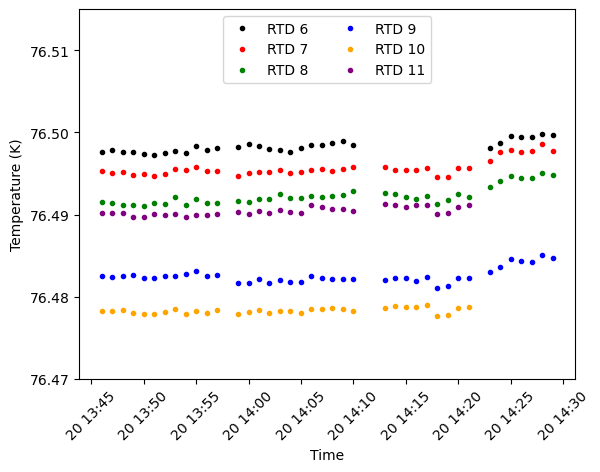

In [7]:
fig, axes = plt.subplots(1, 1)
# axes.plot(dataset.data.index.values, (dataset.data['TE0001']/mux1.data).values, ".", label='RTD 1')
# axes.plot(dataset.data.index.values, (dataset.data['TE0002']/mux1.data).values, ".", label='RTD 2')
# axes.plot(dataset.data.index.values, dataset.data['TE0003'].values, ".", label='RTD 3')
# axes.plot(dataset.data.index.values, dataset.data['TE0004'].values, ".", label='RTD 4')
# axes.plot(dataset.data.index.values, dataset.data['TE0005'].values, ".", label='RTD 5')
# axes.plot(dataset.data.index.values, dataset.data['TE0006'].values, ".", label='RTD 6')
axes.plot(dataset.data.index.values, (dataset.data['TE0007']/mux1.data).values, ".", label='RTD 6', color="black")
axes.plot(dataset.data.index.values, (dataset.data['TE0008']/mux1.data).values, ".", label='RTD 7', color="red")
axes.plot(dataset.data.index.values, (dataset.data['TE0009']/mux1.data).values, ".", label='RTD 8', color="green")
axes.plot(dataset.data.index.values, (dataset.data['TE0010']/mux1.data).values, ".", label='RTD 9', color="blue")
axes.plot(dataset.data.index.values, (dataset.data['TE0011']/mux1.data).values, ".", label='RTD 10', color="orange")
axes.plot(dataset.data.index.values, (dataset.data['TE0012']/mux1.data).values, ".", label='RTD 11', color="purple")
# axes.plot(dataset.data.index.values, dataset.data['TE0009'].values, ".", label='RTD 9')
axes.plot(dataset.data.index.values, (dataset.data['TE0025']/mux1.data).values - 0.0075, ".", color="black")
axes.plot(dataset.data.index.values, (dataset.data['TE0026']/mux2.data).values - 0.0075, ".", color="red")
axes.plot(dataset.data.index.values, (dataset.data['TE0027']/mux2.data).values - 0.0075, ".", color="green")
axes.plot(dataset.data.index.values, (dataset.data['TE0028']/mux2.data).values - 0.0075, ".", color="blue")
axes.plot(dataset.data.index.values, (dataset.data['TE0029']/mux2.data).values - 0.0075, ".", color="orange")
axes.plot(dataset.data.index.values, (dataset.data['TE0030']/mux2.data).values - 0.0075, ".", color="purple")

axes.plot(dataset.data.index.values, (dataset.data['TE0049']/mux3.data).values - 0.021, ".", color="black")
axes.plot(dataset.data.index.values, (dataset.data['TE0050']/mux3.data).values - 0.021, ".", color="red")
axes.plot(dataset.data.index.values, (dataset.data['TE0051']/mux3.data).values - 0.021, ".", color="green")
axes.plot(dataset.data.index.values, (dataset.data['TE0052']/mux3.data).values - 0.021, ".", color="blue")
axes.plot(dataset.data.index.values, (dataset.data['TE0053']/mux3.data).values - 0.021, ".", color="orange")
axes.plot(dataset.data.index.values, (dataset.data['TE0054']/mux3.data).values - 0.021, ".", color="purple")

axes.plot(dataset.data.index.values, (dataset.data['TE0073']*mux4.data/4).values - 0.7765, ".", color="black")
axes.plot(dataset.data.index.values, (dataset.data['TE0074']*mux4.data/4).values - 0.7765, ".", color="red")
axes.plot(dataset.data.index.values, (dataset.data['TE0075']*mux4.data/4).values - 0.7765, ".", color="green")
axes.plot(dataset.data.index.values, (dataset.data['TE0076']*mux4.data/4).values - 0.7765, ".", color="blue")
axes.plot(dataset.data.index.values, (dataset.data['TE0077']*mux4.data/4).values - 0.7765, ".", color="orange")
axes.plot(dataset.data.index.values, (dataset.data['TE0078']*mux4.data/4).values - 0.7765, ".", color="purple")

axes.set_ylim(76.47,76.515)
axes.set_xlabel("Time")
axes.set_ylabel("Temperature (K)")
axes.legend(ncol=2)
# axes.set_ylim(76,77)
axes.tick_params(axis='x', rotation=45);
# axes2 = axes.twinx()
# axes2.plot(mux1.data.index.values, mux1.data.values, "-.", label='MUX 1', color="blue")
# axes2.plot(mux2.data.index.values, mux2.data.values, "-.", label='MUX 2', color="black")
# axes2.plot(mux3.data.index.values, mux3.data.values, "-.", label='MUX 3', color="red")
# axes2.set_ylim(1.00075, 1.002)

ERROR: SensorID (9001) coordinates not found
ERROR: SensorID (9007) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9007
ERROR: SensorID (9008) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9008
ERROR: SensorID (9009) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9009
ERROR: SensorID (9010) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9010
ERROR: SensorID (9011) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9011
ERROR: SensorID (9012) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9012
ERROR: SensorID (9002) coordinates not found
ERROR: SensorID (9007) coordinates not found
Ref Resistor 9002 corrected with Cal Resistor 9007
ERROR: SensorID (9008) coordinates not found
Ref Resistor 9002 corrected with Cal Resistor 9008
ERROR: SensorID (9009) coordinates not found
Ref Resistor 9002 corrected with Cal Resistor 9009
ERROR: SensorID (9010) coordinates not found
R

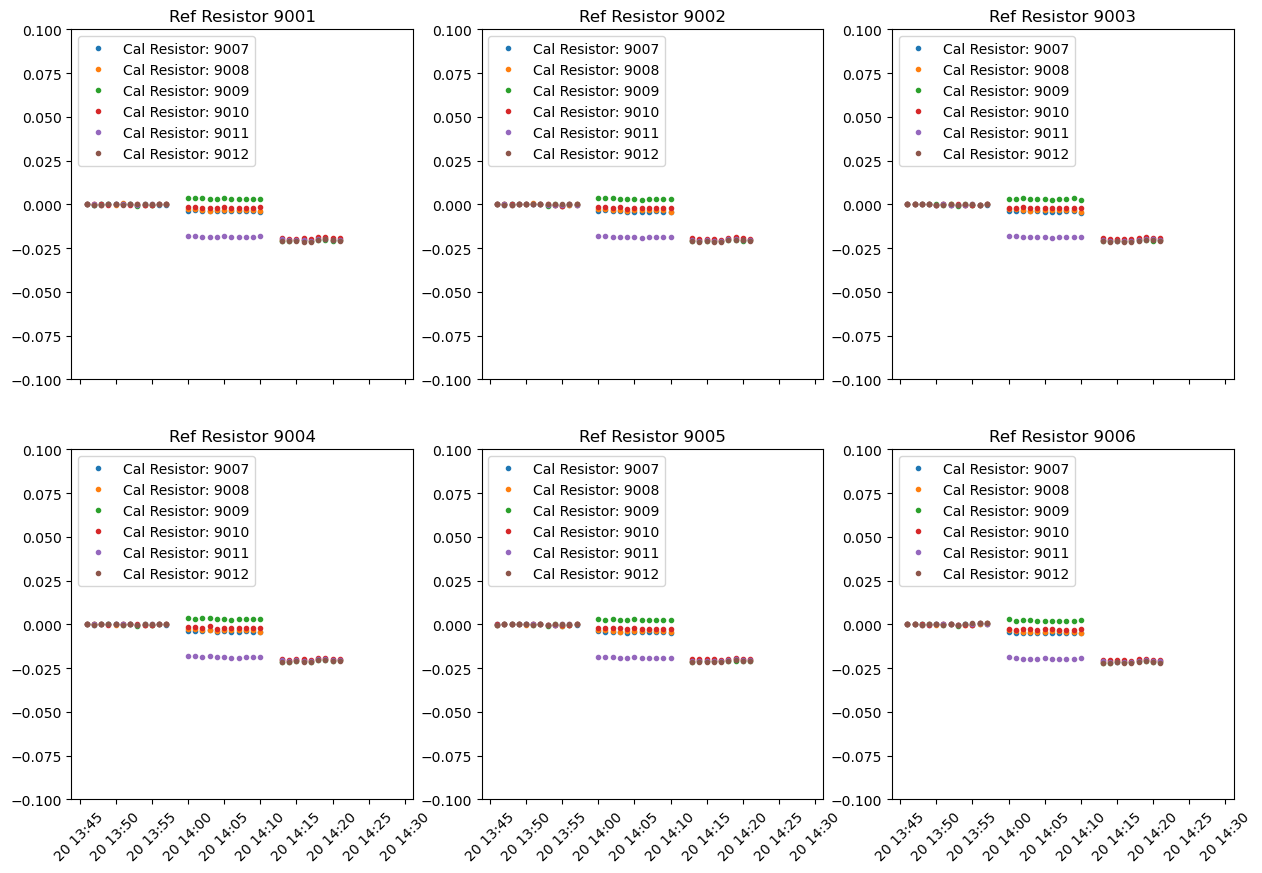

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=True)
axes = axes.flatten()
for i, id in enumerate([9001, 9002, 9003, 9004, 9005, 9006]):
    ref_resistor = sensorClasses.Sensor(dataset=dataset, id=id).muxCorrection()
    for cal_id in [9007, 9008, 9009, 9010, 9011, 9012]:
        cal_resistor = sensorClasses.Sensor(dataset=dataset, id=cal_id).muxCorrection()
        print(f"Ref Resistor {id} corrected with Cal Resistor {cal_id}")
        axes[i].plot((ref_resistor.data - cal_resistor.data).index.values,
                     (ref_resistor.data - cal_resistor.data).values - (ref_resistor.data - cal_resistor.data).loc[((ref_resistor.data - cal_resistor.data).index<datetime.datetime(2024, 9, 20, 13, 55))].mean(), ".", label=f"Cal Resistor: {cal_id}")
    axes[i].set_title(f"Ref Resistor {id}")
    axes[i].legend(ncol=1)
    axes[i].set_ylim(-0.1, 0.1)
    axes[i].tick_params(axis='x', rotation=45)

ERROR: SensorID (9001) coordinates not found
ERROR: SensorID (9001) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9001
ERROR: SensorID (9002) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9002
ERROR: SensorID (9003) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9003
ERROR: SensorID (9004) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9004
ERROR: SensorID (9005) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9005
ERROR: SensorID (9006) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9006
ERROR: SensorID (9007) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9007
ERROR: SensorID (9008) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9008
ERROR: SensorID (9009) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9009
ERROR: SensorID (9010) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 

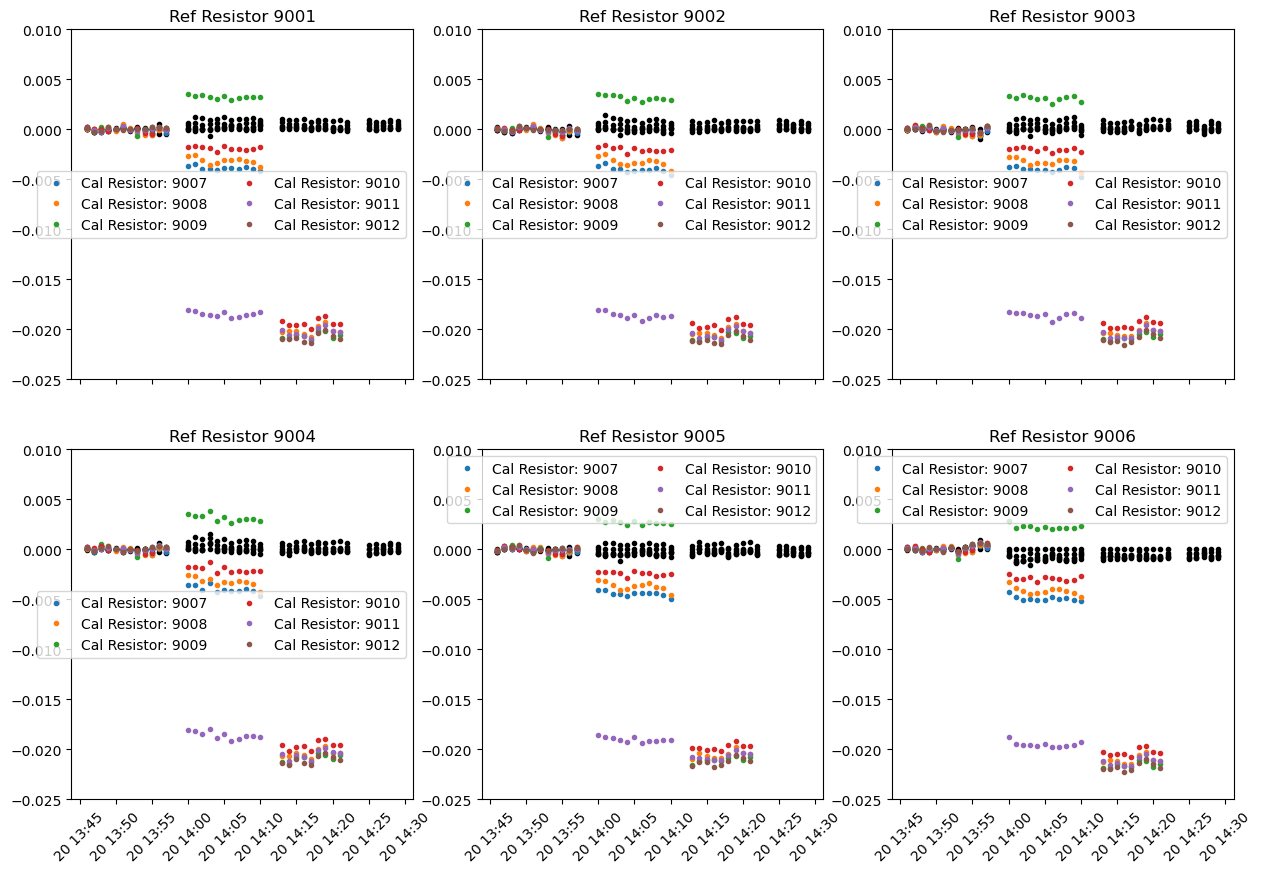

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=True)
axes = axes.flatten()
for i, id in enumerate([9001, 9002, 9003, 9004, 9005, 9006]):
    ref_resistor = sensorClasses.Sensor(dataset=dataset, id=id).muxCorrection()
    for cal_id in [9001, 9002, 9003, 9004, 9005, 9006, 9007, 9008, 9009, 9010, 9011, 9012]:
        cal_resistor = sensorClasses.Sensor(dataset=dataset, id=cal_id).muxCorrection()
        print(f"Ref Resistor {id} corrected with Cal Resistor {cal_id}")
        if cal_id < 9007:
            axes[i].plot((ref_resistor.data - cal_resistor.data).index.values,
                         (ref_resistor.data - cal_resistor.data).values - (ref_resistor.data - cal_resistor.data).loc[((ref_resistor.data - cal_resistor.data).index<datetime.datetime(2024, 9, 20, 13, 55))].mean(), ".", color="black")
        else:
            axes[i].plot((ref_resistor.data - cal_resistor.data).index.values,
                        (ref_resistor.data - cal_resistor.data).values - (ref_resistor.data - cal_resistor.data).loc[((ref_resistor.data - cal_resistor.data).index<datetime.datetime(2024, 9, 20, 13, 55))].mean(), ".", label=f"Cal Resistor: {cal_id}")
    axes[i].set_title(f"Ref Resistor {id}")
    axes[i].legend(ncol=2)
    axes[i].set_ylim(-0.025, 0.01)
    axes[i].tick_params(axis='x', rotation=45)

ERROR: SensorID (9001) coordinates not found
ERROR: SensorID (9001) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9001
ERROR: SensorID (9002) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9002
ERROR: SensorID (9003) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9003
ERROR: SensorID (9004) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9004
ERROR: SensorID (9005) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9005
ERROR: SensorID (9006) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9006
ERROR: SensorID (9007) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9007
ERROR: SensorID (9008) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9008
ERROR: SensorID (9009) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 9009
ERROR: SensorID (9010) coordinates not found
Ref Resistor 9001 corrected with Cal Resistor 

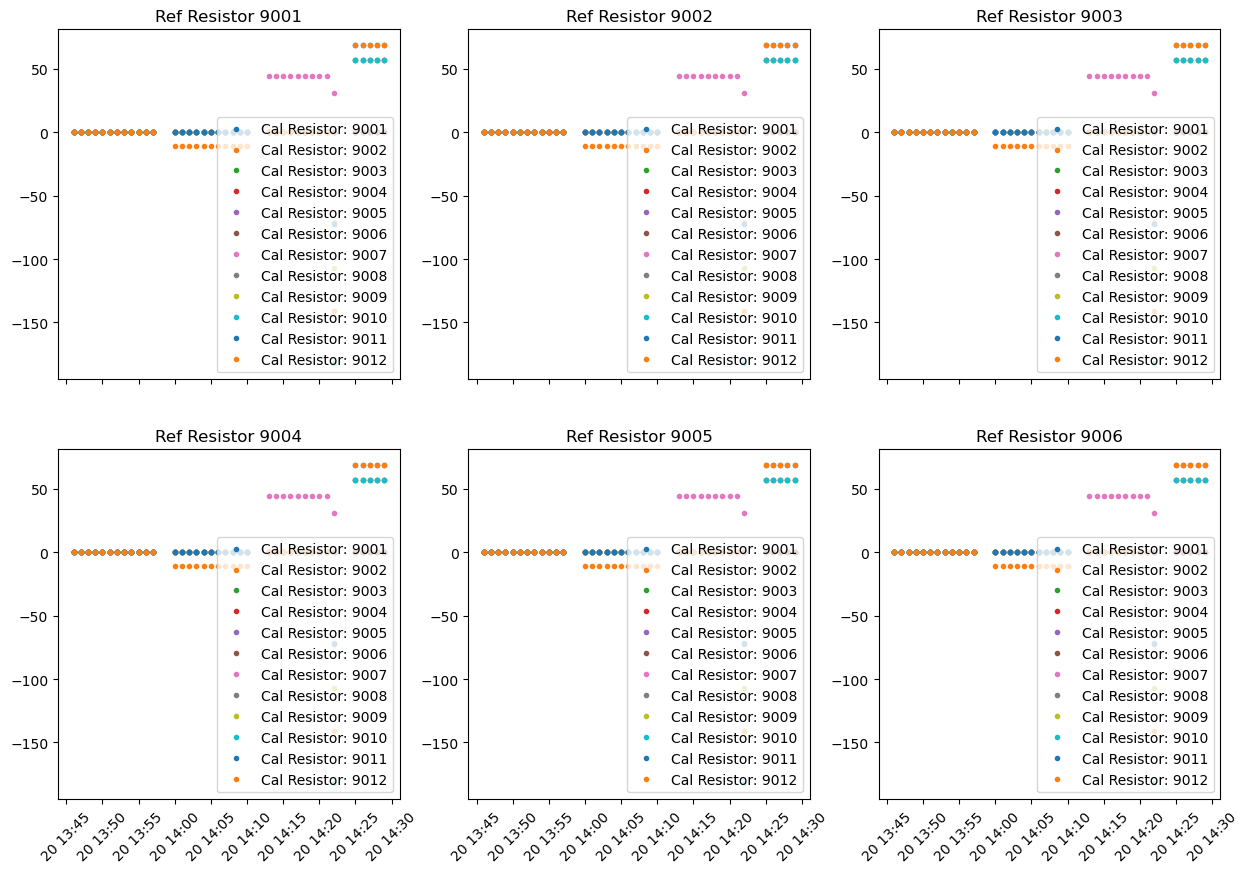

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=True)
axes = axes.flatten()
for i, id in enumerate([9001, 9002, 9003, 9004, 9005, 9006]):
    ref_resistor = sensorClasses.Sensor(dataset=dataset, id=id).muxCorrection()
    for cal_id in [9001, 9002, 9003, 9004, 9005, 9006, 9007, 9008, 9009, 9010, 9011, 9012]:
        cal_resistor = sensorClasses.Sensor(dataset=dataset, id=cal_id).muxCorrection()
        print(f"Ref Resistor {id} corrected with Cal Resistor {cal_id}")
        axes[i].plot((ref_resistor.data - cal_resistor.data).index.values,
                     (ref_resistor.data - cal_resistor.data).values, ".", label=f"Cal Resistor: {cal_id}")
    axes[i].set_title(f"Ref Resistor {id}")
    axes[i].legend(ncol=1)
    # axes[i].set_ylim(0.999, 1.001)
    axes[i].tick_params(axis='x', rotation=45)

ERROR: SensorID (9001) coordinates not found
ERROR: SensorID (9007) coordinates not found
ERROR: SensorID (9008) coordinates not found
ERROR: SensorID (9009) coordinates not found
ERROR: SensorID (9010) coordinates not found
ERROR: SensorID (9011) coordinates not found
ERROR: SensorID (9012) coordinates not found
ERROR: SensorID (9002) coordinates not found
ERROR: SensorID (9007) coordinates not found
ERROR: SensorID (9008) coordinates not found
ERROR: SensorID (9009) coordinates not found
ERROR: SensorID (9010) coordinates not found
ERROR: SensorID (9011) coordinates not found
ERROR: SensorID (9012) coordinates not found
ERROR: SensorID (9003) coordinates not found
ERROR: SensorID (9007) coordinates not found
ERROR: SensorID (9008) coordinates not found
ERROR: SensorID (9009) coordinates not found
ERROR: SensorID (9010) coordinates not found
ERROR: SensorID (9011) coordinates not found
ERROR: SensorID (9012) coordinates not found
ERROR: SensorID (9004) coordinates not found
ERROR: Sen

Text(0, 0.5, 'MUX Equalisation Factor (K)')

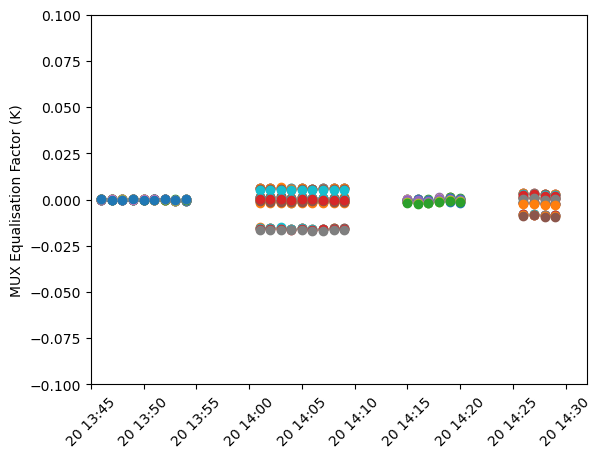

In [102]:
results = {}
for ref_id in [9001, 9002, 9003, 9004, 9005, 9006]:
    ref_resistor = sensorClasses.Sensor(dataset=dataset, id=ref_id).muxCorrection()
    results[ref_id] = {}
    for id in [9007, 9008, 9009, 9010, 9011, 9012]:
        resistor = sensorClasses.Sensor(dataset=dataset, id=id).muxCorrection()
        b1 = (ref_resistor.data - resistor.data).loc[((ref_resistor.data - resistor.data).index> datetime.datetime(2024, 9, 20, 13, 45, 0)) & ((ref_resistor.data - resistor.data).index < datetime.datetime(2024, 9, 20, 13, 55, 0))]
        b2 = (ref_resistor.data - resistor.data).loc[((ref_resistor.data - resistor.data).index> datetime.datetime(2024, 9, 20, 14, 0, 0)) & ((ref_resistor.data - resistor.data).index < datetime.datetime(2024, 9, 20, 14, 10, 0))]
        b3 = (ref_resistor.data - resistor.data).loc[((ref_resistor.data - resistor.data).index> datetime.datetime(2024, 9, 20, 14, 14, 0)) & ((ref_resistor.data - resistor.data).index < datetime.datetime(2024, 9, 20, 14, 21, 0))]
        b4 = (ref_resistor.data - resistor.data).loc[((ref_resistor.data - resistor.data).index> datetime.datetime(2024, 9, 20, 14, 25, 0)) & ((ref_resistor.data - resistor.data).index < datetime.datetime(2024, 9, 20, 14, 30, 0))]
        results[ref_id][id] = {
            "b1": abs(b1.mean() - b1.mean()),
            "b2": abs(b2.mean() - b1.mean()),
            "b3": abs(b3.mean() - b1.mean()),
            "b4": abs(b4.mean() - b1.mean())
        }
        plt.plot(b1.index.values, b1.values - b1.mean(), "o", label=fr"B1: $\mu$={1e3*(b1.mean() - b1.mean()):.1f} mK")
        plt.plot(b2.index.values, b2.values - b1.mean() + 0.003, "o", label=fr"B2: $\mu$={1e3*(b2.mean() - b1.mean()):.1f} mK")
        plt.plot(b3.index.values, b3.values - b1.mean() + 0.02, "o", label=fr"B3: $\mu$={1e3*(b3.mean() - b1.mean()):.1f} mK")
        plt.plot(b4.index.values, b4.values - b1.mean() - 57.446, "o", label=fr"B4: $\mu$={1e3*(b4.mean() - b1.mean()):.1f} mK")
        # plt.plot((resistor.data.loc[(resistor.data>76.3)&(resistor.data<76.7)] - ref_resistor.data.loc[(resistor.data>76.3)&(resistor.data<76.75)]) - (resistor.data.loc[(resistor.data>76.3)&(resistor.data<76.7)] - ref_resistor.data.loc[(resistor.data>76.3)&(resistor.data<76.75)])[0:7].mean(), ".")
plt.xticks(rotation=45);
plt.ylim(-0.1, 0.1)
plt.xlim(datetime.datetime(2024, 9, 20, 13, 45, 0), datetime.datetime(2024, 9, 20, 14, 32, 0))
plt.ylabel("MUX Equalisation Factor (K)")
# plt.legend(loc="upper left", ncol=2)

In [54]:
print(results)

{9001: {9007: {'b1': 0.0, 'b2': 0.0038781714872916, 'b3': 44.48945228217572, 'b4': 57.449233524588266}, 9008: {'b1': 0.0, 'b2': 0.0031292117450744976, 'b3': 0.020085421943575293, 'b4': 57.4472038645312}, 9009: {'b1': 0.0, 'b2': 0.0032245889342669264, 'b3': 0.020569412863042185, 'b4': 57.444285381564654}, 9010: {'b1': 0.0, 'b2': 0.0018971117661250331, 'b3': 0.019330616131716577, 'b4': 57.43790307754438}, 9011: {'b1': 0.0, 'b2': 0.018525919816367618, 'b3': 0.020252608903585982, 'b4': 68.60779832131934}, 9012: {'b1': 0.0, 'b2': 11.113092998198738, 'b3': 0.020757059735346042, 'b4': 68.73939616958165}}, 9002: {9007: {'b1': 0.0, 'b2': 0.003991919016156784, 'b3': 44.489340739293326, 'b4': 57.44913486480206}, 9008: {'b1': 0.0, 'b2': 0.003242959273939682, 'b3': 0.020196964825972136, 'b4': 57.44710520474499}, 9009: {'b1': 0.0, 'b2': 0.003110841405401743, 'b3': 0.02068095574543902, 'b4': 57.44418672177845}, 9010: {'b1': 0.0, 'b2': 0.0020108592949902174, 'b3': 0.019442159014113416, 'b4': 57.437804

In [55]:
for index, value in results.items():
    results[index] = (pd.DataFrame(value).T)
print(results)

{9001:        b1         b2         b3         b4
9007  0.0   0.003878  44.489452  57.449234
9008  0.0   0.003129   0.020085  57.447204
9009  0.0   0.003225   0.020569  57.444285
9010  0.0   0.001897   0.019331  57.437903
9011  0.0   0.018526   0.020253  68.607798
9012  0.0  11.113093   0.020757  68.739396, 9002:        b1         b2         b3         b4
9007  0.0   0.003992  44.489341  57.449135
9008  0.0   0.003243   0.020197  57.447105
9009  0.0   0.003111   0.020681  57.444187
9010  0.0   0.002011   0.019442  57.437804
9011  0.0   0.018640   0.020364  68.607700
9012  0.0  11.113207   0.020869  68.739298, 9003:        b1         b2         b3         b4
9007  0.0   0.003963  44.489322  57.449069
9008  0.0   0.003214   0.020216  57.447040
9009  0.0   0.003140   0.020700  57.444121
9010  0.0   0.001982   0.019461  57.437739
9011  0.0   0.018611   0.020383  68.607634
9012  0.0  11.113178   0.020887  68.739232, 9004:        b1         b2         b3         b4
9007  0.0   0.003964  44.4

In [56]:
concat_df = pd.concat(results, axis=0)

In [57]:
print(concat_df)

            b1         b2         b3         b4
9001 9007  0.0   0.003878  44.489452  57.449234
     9008  0.0   0.003129   0.020085  57.447204
     9009  0.0   0.003225   0.020569  57.444285
     9010  0.0   0.001897   0.019331  57.437903
     9011  0.0   0.018526   0.020253  68.607798
     9012  0.0  11.113093   0.020757  68.739396
9002 9007  0.0   0.003992  44.489341  57.449135
     9008  0.0   0.003243   0.020197  57.447105
     9009  0.0   0.003111   0.020681  57.444187
     9010  0.0   0.002011   0.019442  57.437804
     9011  0.0   0.018640   0.020364  68.607700
     9012  0.0  11.113207   0.020869  68.739298
9003 9007  0.0   0.003963  44.489322  57.449069
     9008  0.0   0.003214   0.020216  57.447040
     9009  0.0   0.003140   0.020700  57.444121
     9010  0.0   0.001982   0.019461  57.437739
     9011  0.0   0.018611   0.020383  68.607634
     9012  0.0  11.113178   0.020887  68.739232
9004 9007  0.0   0.003964  44.489245  57.448931
     9008  0.0   0.003215   0.020292  57

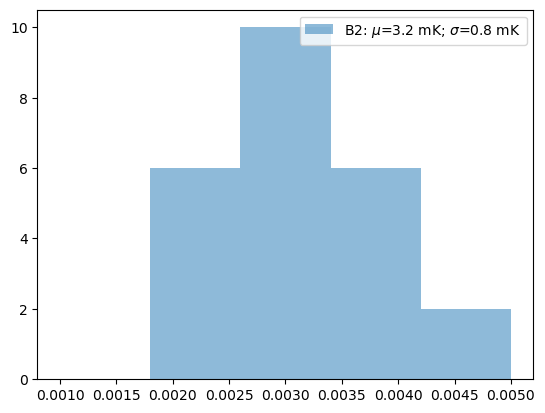

In [70]:
plt.hist(concat_df["b2"].values, range=(0.001, 0.005), bins=5, alpha=0.5, label=fr"B2: $\mu$={1e3*concat_df['b2'].loc[(concat_df['b2']<0.01)].mean():.1f} mK; $\sigma$={1e3*concat_df['b2'].loc[(concat_df['b2']<0.01)].std():.1f} mK")
plt.legend()

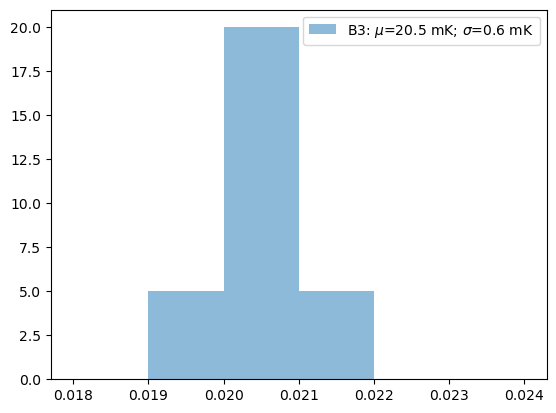

In [73]:
plt.hist(concat_df["b3"].values, range=(0.018, 0.024), bins=6, alpha=0.5, label=fr"B3: $\mu$={1e3*concat_df['b3'].loc[(concat_df['b3']<0.025)].mean():.1f} mK; $\sigma$={1e3*concat_df['b3'].loc[(concat_df['b3']<0.025)].std():.1f} mK")
plt.legend()

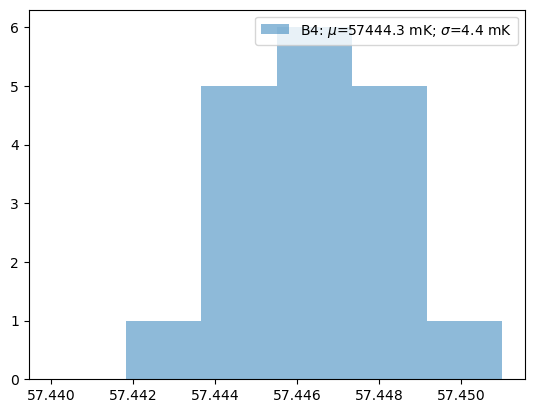

In [88]:
plt.hist(concat_df["b4"].values, range=(57.440, 57.451), bins=6, alpha=0.5, label=fr"B4: $\mu$={1e3*concat_df['b4'].loc[(concat_df['b4']<57.451)].mean():.1f} mK; $\sigma$={1e3*concat_df['b4'].loc[(concat_df['b4']<57.451)].std():.1f} mK")
plt.legend()

In [89]:
final_results = {
    1: 0,
    2: 3.2,
    3:20.5,
    4:57444.3
}

with open("/eos/user/j/jcapotor/RTDdata/corrections/equalisation_final_results.pkl", "wb") as f:
    pickle.dump(final_results, f)